# MODELO NAÏVE:

In [ ]:
# Importar librería para manipulación de datos
import pandas as pd  # Permite trabajar con tablas y estructuras tipo DataFrame

# Importar librería para operaciones numéricas
import numpy as np  # Permite trabajar con arrays y operaciones matemáticas

# Importar librería para visualización
import matplotlib.pyplot as plt  # Permite construir gráficos de resultados

# Importar métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error  # Permite calcular MAE y RMSE

# Configurar tamaño por defecto de las figuras
plt.rcParams["figure.figsize"] = (12, 5)  # Define un tamaño estándar para los gráficos

# Activar cuadrícula por defecto
plt.rcParams["axes.grid"] = True  # Facilita la lectura visual de los gráficos

In [ ]:
# Cargar el archivo CSV con la serie agregada de Galicia
df = pd.read_csv("bbdd_biogas_galicia.csv")  # Lee la base de datos desde el archivo CSV

# Convertir la columna datetime al formato de fecha
df["datetime"] = pd.to_datetime(df["datetime"])  # Asegura que pandas interprete correctamente las fechas

# Ordenar las observaciones cronológicamente
df = df.sort_values("datetime")  # Garantiza que la serie esté ordenada temporalmente

# Resetear el índice después de ordenar
df = df.reset_index(drop=True)  # Evita conservar el índice anterior tras la ordenación

# Seleccionar las columnas necesarias para el modelado
df_model = df[["datetime", "generacion_biogas_mwh"]].copy()  # Crea una copia limpia con fecha y variable objetivo

# Extraer la serie objetivo como array de NumPy
serie = df_model["generacion_biogas_mwh"].values  # Convierte la generación de biogás en un array

# Mostrar información básica de la serie
print("Número total de observaciones:", len(serie))  # Muestra el tamaño total de la serie

# Mostrar fecha inicial
print("Fecha inicial:", df_model["datetime"].min())  # Muestra la primera fecha disponible

# Mostrar fecha final
print("Fecha final:", df_model["datetime"].max())  # Muestra la última fecha disponible

# Mostrar primeros valores
print("\nPrimeros 5 valores de la serie:")  # Introduce la visualización inicial

# Imprimir los primeros cinco valores
print(serie[:5])  # Permite comprobar que la serie se ha cargado correctamente

Número total de observaciones: 3638
Fecha inicial: 2016-04-06 00:00:00
Fecha final: 2026-03-22 00:00:00

Primeros 5 valores de la serie:
[ 78.426  78.66   84.376 100.137  84.765]


**División cronológica en train, validation y test**

En este bloque se divide la serie en entrenamiento, validación y test usando las mismas proporciones que en los modelos RNN, LSTM y GRU: 70%, 15% y 15%. Aunque el modelo naïve no requiere entrenamiento, la división en conjuntos de entrenamiento, validación y test se mantiene para garantizar la consistencia metodológica y la comparabilidad de resultados con los modelos de deep learrning. De este modo, todas las arquitecturas se evalúan bajo las mismas condiciones temporales, evitando fugas de información y permitiendo una comparación justa del rendimiento predictivo.

In [ ]:
# Definir proporción del conjunto de entrenamiento
train_ratio = 0.70  # El 70% inicial de la serie se reserva como tramo de entrenamiento

# Definir proporción del conjunto de validación
val_ratio = 0.15  # El siguiente 15% se reserva como tramo de validación

# Definir proporción del conjunto de test
test_ratio = 0.15  # El último 15% se reserva como tramo de test

# Calcular el número total de observaciones
n_total = len(serie)  # Obtiene la longitud completa de la serie

# Calcular el índice final del conjunto de entrenamiento
train_end = int(n_total * train_ratio)  # Marca el punto de corte entre train y validation

# Calcular el índice final del conjunto de validación
val_end = int(n_total * (train_ratio + val_ratio))  # Marca el punto de corte entre validation y test

# Crear conjunto de entrenamiento
train = serie[:train_end]  # Contiene el primer tramo temporal de la serie

# Crear conjunto de validación
val = serie[train_end:val_end]  # Contiene el tramo temporal usado para validación

# Crear conjunto de test
test = serie[val_end:]  # Contiene el tramo final reservado para evaluación

# Crear fechas de entrenamiento
dates_train = df_model["datetime"].iloc[:train_end].values  # Fechas correspondientes al conjunto train

# Crear fechas de validación
dates_val = df_model["datetime"].iloc[train_end:val_end].values  # Fechas correspondientes al conjunto validation

# Crear fechas de test
dates_test = df_model["datetime"].iloc[val_end:].values  # Fechas correspondientes al conjunto test

# Mostrar tamaño del conjunto de entrenamiento
print("Tamaño train:", len(train))  # Comprueba el número de observaciones de train

# Mostrar tamaño del conjunto de validación
print("Tamaño validation:", len(val))  # Comprueba el número de observaciones de validation

# Mostrar tamaño del conjunto de test
print("Tamaño test:", len(test))  # Comprueba el número de observaciones de test

Tamaño train: 2546
Tamaño validation: 546
Tamaño test: 546


**Definición del modelo naïve**

En esta celda se construyen las predicciones del modelo naïve. Para cada observación, la predicción es simplemente el valor inmediatamente anterior. En validación, la primera predicción utiliza el último valor del conjunto de entrenamiento. En test, la primera predicción utiliza el último valor del conjunto de validación. Así se respeta la lógica temporal del problema y no se utiliza información futura.

In [ ]:
# Crear valores reales de validación
y_val_real = val  # Los valores reales de validación son la serie observada en validation

# Crear predicciones naïve para validación
y_val_pred = np.concatenate([[train[-1]], val[:-1]])  # La primera predicción usa el último valor de train y el resto usa el valor anterior de validation

# Crear valores reales de test
y_test_real = test  # Los valores reales de test son la serie observada en test

# Crear predicciones naïve para test
y_test_pred = np.concatenate([[val[-1]], test[:-1]])  # La primera predicción usa el último valor de validation y el resto usa el valor anterior de test

# Mostrar las dimensiones de los arrays de validación
print("y_val_real:", y_val_real.shape)  # Comprueba el tamaño de los valores reales de validation

# Mostrar las dimensiones de las predicciones de validación
print("y_val_pred:", y_val_pred.shape)  # Comprueba el tamaño de las predicciones de validation

# Mostrar las dimensiones de los arrays de test
print("y_test_real:", y_test_real.shape)  # Comprueba el tamaño de los valores reales de test

# Mostrar las dimensiones de las predicciones de test
print("y_test_pred:", y_test_pred.shape)  # Comprueba el tamaño de las predicciones de test

y_val_real: (546,)
y_val_pred: (546,)
y_test_real: (546,)
y_test_pred: (546,)


**Cálculo de métricas en el conjunto de entrenamiento**

Para completar el análisis del comportamiento del modelo y poder contrastar el rendimiento dentro y fuera de muestra, se calculan también las métricas en el conjunto de entrenamiento. El modelo naïve se aplica con la misma lógica que en validación y test: la predicción de cada día se construye como el valor del día inmediatamente anterior.

In [ ]:
# Crear valores reales de train
y_train_real_naive = train[1:]  # Se descarta la primera observación porque no tiene día anterior

# Crear predicciones naïve para train
y_train_pred_naive = train[:-1]  # Cada predicción es el valor del día anterior

# Calcular MAE en train
mae_train_naive = mean_absolute_error(y_train_real_naive, y_train_pred_naive)  # Error absoluto medio en train

# Calcular RMSE en train
rmse_train_naive = np.sqrt(mean_squared_error(y_train_real_naive, y_train_pred_naive))  # Raíz del error cuadrático medio en train

# Mostrar título de resultados
print("Métricas del modelo Naïve en train")

# Mostrar MAE de train
print(f"MAE train:  {mae_train_naive:.3f} MWh")

# Mostrar RMSE de train
print(f"RMSE train: {rmse_train_naive:.3f} MWh")

Métricas del modelo Naïve en train
MAE train:  12.112 MWh
RMSE train: 34.127 MWh


**Cálculo de métricas del modelo naïve**

En este bloque se calculan las métricas principales del modelo naïve en validación y test. Se utilizan MAE y RMSE, igual que en los modelos RNN, LSTM y GRU. Estas métricas permitirán comprobar si los modelos de deep learning realmente mejoran frente a una referencia muy simple.

In [ ]:
# Calcular MAE en validation
mae_val_naive = mean_absolute_error(y_val_real, y_val_pred)  # Error absoluto medio en validación

# Calcular RMSE en validation
rmse_val_naive = np.sqrt(mean_squared_error(y_val_real, y_val_pred))  # Raíz del error cuadrático medio en validación

# Calcular MAE en test
mae_test_naive = mean_absolute_error(y_test_real, y_test_pred)  # Error absoluto medio en test

# Calcular RMSE en test
rmse_test_naive = np.sqrt(mean_squared_error(y_test_real, y_test_pred))  # Raíz del error cuadrático medio en test

# Mostrar título de resultados
print("Resultados finales del modelo Naïve")  # Identifica la salida del modelo

# Mostrar MAE de validación
print(f"MAE validation:  {mae_val_naive:.3f} MWh")  # Imprime MAE de validation en MWh

# Mostrar RMSE de validación
print(f"RMSE validation: {rmse_val_naive:.3f} MWh")  # Imprime RMSE de validation en MWh

# Mostrar MAE de test
print(f"MAE test:        {mae_test_naive:.3f} MWh")  # Imprime MAE de test en MWh

# Mostrar RMSE de test
print(f"RMSE test:       {rmse_test_naive:.3f} MWh")  # Imprime RMSE de test en MWh

Resultados finales del modelo Naïve
MAE validation:  10.206 MWh
RMSE validation: 12.763 MWh
MAE test:        9.718 MWh
RMSE test:       12.289 MWh


**Tabla resumen del modelo naïve**

In [ ]:
# Crear un diccionario con las métricas del modelo naïve
metrics_naive = {
    "Modelo": ["Naïve"],  # Nombre del modelo evaluado
    "MAE train": [mae_train_naive],  # MAE obtenido en train
    "RMSE train": [rmse_train_naive],  # RMSE obtenido en train
    "MAE validation": [mae_val_naive],  # MAE obtenido en validación
    "RMSE validation": [rmse_val_naive],  # RMSE obtenido en validación
    "MAE test": [mae_test_naive],  # MAE obtenido en test
    "RMSE test": [rmse_test_naive]  # RMSE obtenido en test
}

# Convertir el diccionario en DataFrame
tabla_naive = pd.DataFrame(metrics_naive)  # Crea una tabla con las métricas del modelo

# Redondear columnas numéricas a tres decimales
tabla_naive[["MAE train", "RMSE train", "MAE validation", "RMSE validation", "MAE test", "RMSE test"]] = tabla_naive[["MAE train", "RMSE train", "MAE validation", "RMSE validation", "MAE test", "RMSE test"]].round(3)  # Facilita la lectura de resultados

# Mostrar tabla resumen
tabla_naive  # Muestra la tabla final en formato DataFrame

,Modelo,MAE train,RMSE train,MAE validation,RMSE validation,MAE test,RMSE test
0,Naïve,12.112,34.127,10.206,12.763,9.718,12.289


**Comparación gráfica entre valores reales y predichos en test**

En esta celda se representa una parte del conjunto de test comparando los valores reales con las predicciones del modelo naïve. Esta visualización permite observar cómo se comporta el baseline frente a la dinámica real de la serie y servirá después para compararlo visualmente con los modelos de deep learning.

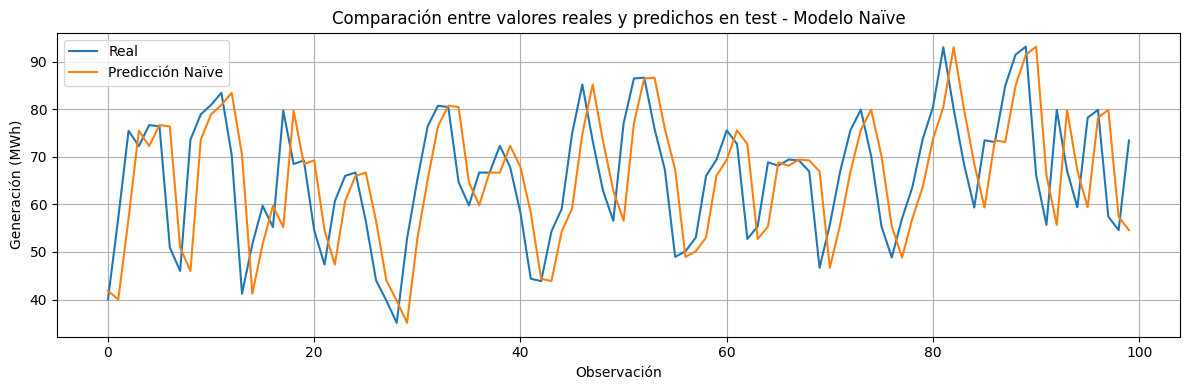

In [ ]:
# Definir número de observaciones a mostrar
n_mostrar = 100  # Número de puntos del test que se representarán

# Crear figura
plt.figure(figsize=(12, 4))  # Define el tamaño del gráfico

# Representar valores reales del test
plt.plot(y_test_real[:n_mostrar], label="Real")  # Dibuja la serie real observada

# Representar predicciones naïve del test
plt.plot(y_test_pred[:n_mostrar], label="Predicción Naïve")  # Dibuja las predicciones del modelo naïve

# Añadir título
plt.title("Comparación entre valores reales y predichos en test - Modelo Naïve")  # Título del gráfico

# Añadir etiqueta del eje X
plt.xlabel("Observación")  # Identifica las observaciones del conjunto de test

# Añadir etiqueta del eje Y
plt.ylabel("Generación (MWh)")  # Indica la unidad de la variable objetivo

# Añadir leyenda
plt.legend()  # Muestra la identificación de cada línea

# Ajustar diseño
plt.tight_layout()  # Mejora la distribución visual del gráfico

# Mostrar gráfico
plt.show()  # Renderiza el gráfico

**Gráfico amplio de train, validation y test**

Este último bloque representa la serie completa separando los tramos de entrenamiento, validación y test. Además, se añaden las predicciones naïve en validación y test. Este gráfico permite visualizar el comportamiento del modelo baseline en el contexto completo de la serie temporal.

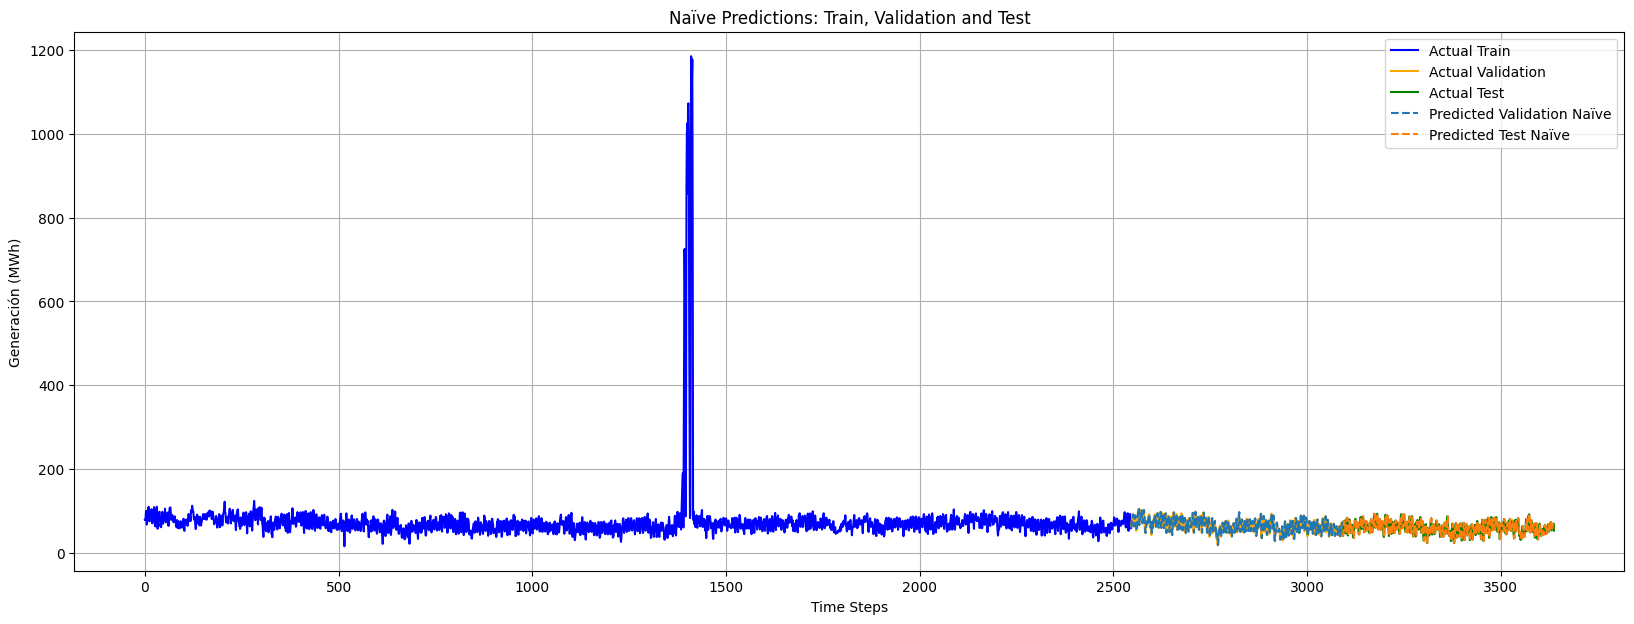

In [ ]:
# Crear eje temporal para train
train_time_steps = range(len(train))  # Índices temporales del tramo de entrenamiento

# Crear eje temporal para validation
val_time_steps = range(len(train), len(train) + len(val))  # Índices temporales del tramo de validación

# Crear eje temporal para test
test_time_steps = range(len(train) + len(val), len(train) + len(val) + len(test))  # Índices temporales del tramo de test

# Crear figura grande
plt.figure(figsize=(20, 7))  # Define un tamaño amplio para visualizar toda la serie

# Representar serie real de entrenamiento
plt.plot(train_time_steps, train, label="Actual Train", color="blue")  # Dibuja la serie real de entrenamiento

# Representar serie real de validación
plt.plot(val_time_steps, y_val_real, label="Actual Validation", color="orange")  # Dibuja la serie real de validación

# Representar serie real de test
plt.plot(test_time_steps, y_test_real, label="Actual Test", color="green")  # Dibuja la serie real de test

# Representar predicción naïve en validación
plt.plot(val_time_steps, y_val_pred, label="Predicted Validation Naïve", linestyle="--")  # Dibuja predicciones naïve en validation

# Representar predicción naïve en test
plt.plot(test_time_steps, y_test_pred, label="Predicted Test Naïve", linestyle="--")  # Dibuja predicciones naïve en test

# Añadir título
plt.title("Naïve Predictions: Train, Validation and Test")  # Título del gráfico

# Añadir etiqueta del eje X
plt.xlabel("Time Steps")  # Identifica el eje temporal

# Añadir etiqueta del eje Y
plt.ylabel("Generación (MWh)")  # Indica la unidad de generación eléctrica

# Añadir leyenda
plt.legend()  # Muestra las etiquetas de cada serie

# Activar cuadrícula
plt.grid(True)  # Mejora la lectura visual

# Mostrar gráfico
plt.show()  # Renderiza la figura

 **Evolución del error del modelo**

En este bloque final se analiza la evolución temporal del error absoluto del modelo naïve a lo largo de train, validation y test. A diferencia de la curva de pérdida que solo se calcula en modelos paramétricos durante el entrenamiento, esta visualización permite estudiar día a día cómo se comporta el error de predicción sobre las observaciones reales. El primer gráfico muestra el error absoluto en cada día de la serie, marcando los tramos de train, validation y test. El segundo gráfico complementa el análisis mediante un boxplot que sintetiza la distribución del error en cada conjunto, lo que facilita detectar si existen diferencias sistemáticas en magnitud o dispersión entre las tres particiones.

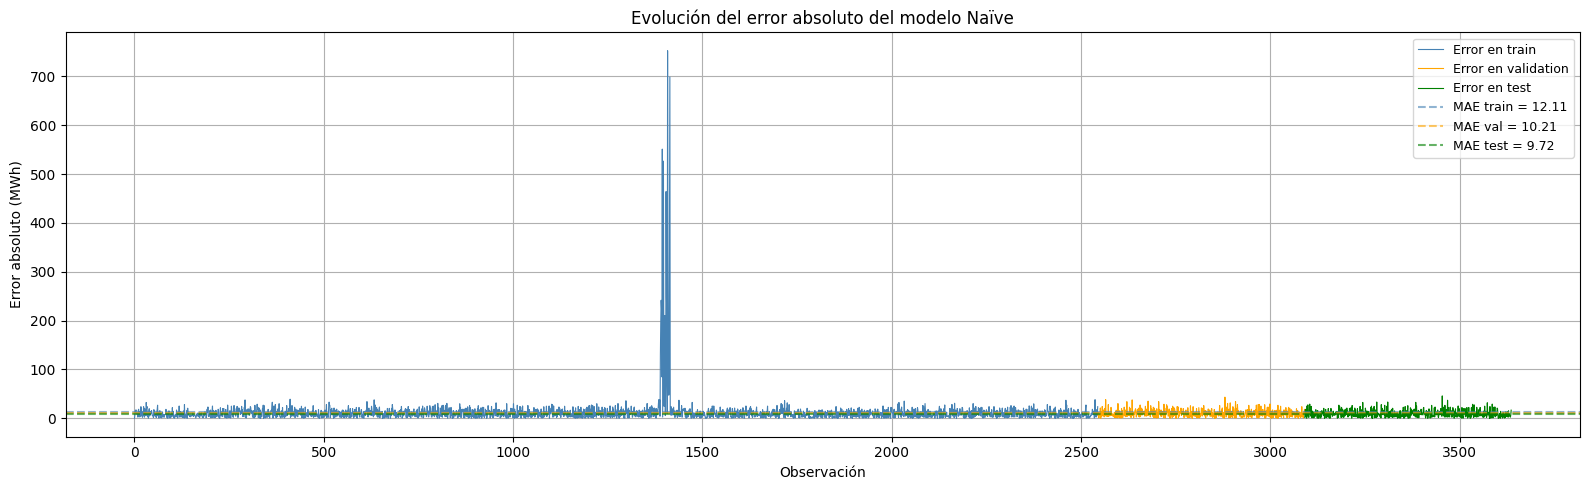

/tmp/ipykernel_274/3376008057.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(errores, labels=["Train", "Validation", "Test"], showfliers=True)


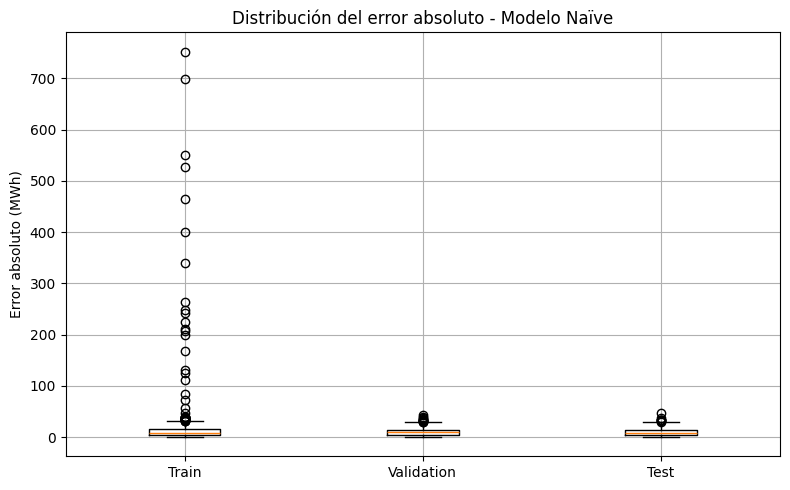

In [ ]:
# Calcular el error absoluto en train
err_train = np.abs(y_train_real_naive - y_train_pred_naive)  # Error absoluto día a día en train

# Calcular el error absoluto en validation
err_val = np.abs(y_val_real - y_val_pred)  # Error absoluto día a día en validation

# Calcular el error absoluto en test
err_test = np.abs(y_test_real - y_test_pred)  # Error absoluto día a día en test

# Crear ejes temporales encadenados para representar todo en un mismo gráfico
x_train = np.arange(len(err_train))                                       # Eje X de train
x_val = np.arange(len(err_train), len(err_train) + len(err_val))          # Eje X de validation
x_test = np.arange(len(err_train) + len(err_val),
                   len(err_train) + len(err_val) + len(err_test))         # Eje X de test

# Crear figura para la evolución temporal del error
plt.figure(figsize=(16, 5))  # Tamaño amplio para visualizar toda la serie

# Representar error absoluto en train
plt.plot(x_train, err_train, label="Error en train", color="steelblue", linewidth=0.8)

# Representar error absoluto en validation
plt.plot(x_val, err_val, label="Error en validation", color="orange", linewidth=0.8)

# Representar error absoluto en test
plt.plot(x_test, err_test, label="Error en test", color="green", linewidth=0.8)

# Añadir línea horizontal con el MAE medio de cada conjunto
plt.axhline(mae_train_naive, color="steelblue", linestyle="--", alpha=0.6, label=f"MAE train = {mae_train_naive:.2f}")
plt.axhline(mae_val_naive, color="orange", linestyle="--", alpha=0.6, label=f"MAE val = {mae_val_naive:.2f}")
plt.axhline(mae_test_naive, color="green", linestyle="--", alpha=0.6, label=f"MAE test = {mae_test_naive:.2f}")

# Añadir título y etiquetas
plt.title("Evolución del error absoluto del modelo Naïve")
plt.xlabel("Observación")
plt.ylabel("Error absoluto (MWh)")
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

# Crear figura para el boxplot de los errores por conjunto
plt.figure(figsize=(8, 5))  # Tamaño moderado

# Construir lista con los tres arrays de error
errores = [err_train, err_val, err_test]  # Lista con los tres errores

# Representar boxplot
plt.boxplot(errores, labels=["Train", "Validation", "Test"], showfliers=True)

# Añadir título y etiquetas
plt.title("Distribución del error absoluto - Modelo Naïve")
plt.ylabel("Error absoluto (MWh)")
plt.tight_layout()
plt.show()

**Segundo modelo de referencia: Media Móvil**

Además del modelo naïve clásico, se incorpora un segundo modelo de referencia basado en la media móvil. Mientras que el modelo naïve predice el valor futuro tomando como referencia el último valor observado, la media móvil genera la predicción a partir del promedio de una ventana reciente de observaciones. Esto proporciona un segundo punto de comparación sencillo, pero algo más suavizado, que reduce el impacto de las fluctuaciones puntuales de la serie de generación eléctrica.

Al igual que el modelo naïve, la media móvil no requiere entrenamiento paramétrico y respeta la lógica temporal del problema: cada predicción se construye únicamente a partir de información pasada, evitando cualquier fuga de información futura. Se mantienen las mismas particiones (train, validation y test) y las mismas métricas (MAE y RMSE) para garantizar la comparabilidad con el modelo *naïve* y con los modelos de deep learning (RNN, LSTM y GRU).

**Definición de la ventana de la media móvil**

En esta celda se define el tamaño de la ventana de la media móvil, es decir, el número de observaciones pasadas que se promedian para generar cada predicción. Se elige una ventana de 7 días, coherente con la naturaleza diaria de la serie de generación eléctrica, ya que captura el comportamiento de una semana completa. Este valor puede ajustarse, pero se fija de antemano para que el modelo sea reproducible y comparable con el resto de modelos.

In [ ]:
# Definir el tamaño de la ventana de la media móvil
window_size = 7  # Número de observaciones pasadas que se promedian para cada predicción

# Mostrar el tamaño de ventana seleccionado
print("Tamaño de ventana de la media móvil:", window_size)  # Comprueba el valor de la ventana

Tamaño de ventana de la media móvil: 7


**Construcción de las predicciones de la media móvil**

En esta celda se construyen las predicciones del modelo de media móvil para validación y test. Para cada observación, la predicción es el promedio de las window_size observaciones inmediatamente anteriores. Para respetar la lógica temporal y no usar información futura, las ventanas que caen al inicio de validación y test se completan con los últimos valores del conjunto anterior (train para validación, y train+validation para test). De este modo, la primera predicción de cada tramo se apoya únicamente en datos pasados, igual que ocurre con el modelo *naïve*.

In [ ]:
# Definir una función que genera predicciones de media móvil respetando la lógica temporal
def moving_average_forecast(serie_objetivo, historia_previa, window):
    # Concatenar el historial previo con la serie objetivo para disponer de contexto pasado
    serie_extendida = np.concatenate([historia_previa, serie_objetivo])  # Une el pasado con el tramo a predecir

    # Calcular el índice donde empieza el tramo objetivo dentro de la serie extendida
    inicio = len(historia_previa)  # Marca el primer punto del tramo que se quiere predecir

    # Crear lista vacía para almacenar las predicciones
    predicciones = []  # Contendrá la predicción de cada observación del tramo objetivo

    # Recorrer cada posición del tramo objetivo
    for i in range(inicio, len(serie_extendida)):
        # Tomar la ventana de los 'window' valores inmediatamente anteriores
        ventana = serie_extendida[i - window:i]  # Selecciona las observaciones pasadas

        # Calcular el promedio de la ventana como predicción
        predicciones.append(np.mean(ventana))  # Añade la media de la ventana a las predicciones

    # Devolver las predicciones como array de NumPy
    return np.array(predicciones)  # Convierte la lista en array para su posterior uso


# Crear valores reales de validación (idénticos a los del modelo naïve)
y_val_real_ma = val  # Los valores reales de validación son la serie observada en validation

# Crear predicciones de media móvil para validación usando train como historia previa
y_val_pred_ma = moving_average_forecast(val, train, window_size)  # Promedia la ventana previa para cada día de validation

# Crear valores reales de test (idénticos a los del modelo naïve)
y_test_real_ma = test  # Los valores reales de test son la serie observada en test

# Crear predicciones de media móvil para test usando train+validation como historia previa
y_test_pred_ma = moving_average_forecast(test, np.concatenate([train, val]), window_size)  # Promedia la ventana previa para cada día de test

# Mostrar las dimensiones de los arrays de validación
print("y_val_real_ma:", y_val_real_ma.shape)  # Comprueba el tamaño de los valores reales de validation

# Mostrar las dimensiones de las predicciones de validación
print("y_val_pred_ma:", y_val_pred_ma.shape)  # Comprueba el tamaño de las predicciones de validation

# Mostrar las dimensiones de los arrays de test
print("y_test_real_ma:", y_test_real_ma.shape)  # Comprueba el tamaño de los valores reales de test

# Mostrar las dimensiones de las predicciones de test
print("y_test_pred_ma:", y_test_pred_ma.shape)  # Comprueba el tamaño de las predicciones de test

y_val_real_ma: (546,)
y_val_pred_ma: (546,)
y_test_real_ma: (546,)
y_test_pred_ma: (546,)


**Cálculo de métricas de la media móvil en el conjunto de entrenamiento**

Para poder contrastar el rendimiento dentro y fuera de muestra, se calculan las métricas de la media móvil también en el conjunto de entrenamiento. Se aplica la misma lógica: cada predicción es el promedio de las window_size observaciones anteriores. Se descartan las primeras observaciones de train que no disponen de una ventana completa de valores previos.

In [ ]:
# Crear predicciones de media móvil para train (a partir de la primera ventana completa)
y_train_pred_ma = moving_average_forecast(train[window_size:], train[:window_size], window_size)  # Promedia la ventana previa para cada día de train

# Crear valores reales de train alineados con las predicciones
y_train_real_ma = train[window_size:]  # Se descartan las primeras observaciones sin ventana completa

# Calcular MAE en train
mae_train_ma = mean_absolute_error(y_train_real_ma, y_train_pred_ma)  # Error absoluto medio en train

# Calcular RMSE en train
rmse_train_ma = np.sqrt(mean_squared_error(y_train_real_ma, y_train_pred_ma))  # Raíz del error cuadrático medio en train

# Mostrar título de resultados
print("Métricas del modelo Media Móvil en train")

# Mostrar MAE de train
print(f"MAE train:  {mae_train_ma:.3f} MWh")

# Mostrar RMSE de train
print(f"RMSE train: {rmse_train_ma:.3f} MWh")

Métricas del modelo Media Móvil en train
MAE train:  15.451 MWh
RMSE train: 54.084 MWh


**Cálculo de métricas del modelo de media móvil**

En este bloque se calculan las métricas principales del modelo de media móvil en validación y test. Se utilizan MAE y RMSE, igual que en el modelo naïve y en los modelos RNN, LSTM y GRU, lo que permite una comparación directa y justa entre todos los modelos de referencia y de deep learning.

In [ ]:
# Calcular MAE en validation
mae_val_ma = mean_absolute_error(y_val_real_ma, y_val_pred_ma)  # Error absoluto medio en validación

# Calcular RMSE en validation
rmse_val_ma = np.sqrt(mean_squared_error(y_val_real_ma, y_val_pred_ma))  # Raíz del error cuadrático medio en validación

# Calcular MAE en test
mae_test_ma = mean_absolute_error(y_test_real_ma, y_test_pred_ma)  # Error absoluto medio en test

# Calcular RMSE en test
rmse_test_ma = np.sqrt(mean_squared_error(y_test_real_ma, y_test_pred_ma))  # Raíz del error cuadrático medio en test

# Mostrar título de resultados
print("Resultados finales del modelo Media Móvil")  # Identifica la salida del modelo

# Mostrar MAE de validación
print(f"MAE validation:  {mae_val_ma:.3f} MWh")  # Imprime MAE de validation en MWh

# Mostrar RMSE de validación
print(f"RMSE validation: {rmse_val_ma:.3f} MWh")  # Imprime RMSE de validation en MWh

# Mostrar MAE de test
print(f"MAE test:        {mae_test_ma:.3f} MWh")  # Imprime MAE de test en MWh

# Mostrar RMSE de test
print(f"RMSE test:       {rmse_test_ma:.3f} MWh")  # Imprime RMSE de test en MWh

Resultados finales del modelo Media Móvil
MAE validation:  11.371 MWh
RMSE validation: 13.753 MWh
MAE test:        11.021 MWh
RMSE test:       13.387 MWh


**Tabla resumen del modelo de media móvil**

In [ ]:
# Crear un diccionario con las métricas del modelo de media móvil
metrics_ma = {
    "Modelo": [f"Media Móvil ({window_size}d)"],  # Nombre del modelo evaluado
    "MAE train": [mae_train_ma],  # MAE obtenido en train
    "RMSE train": [rmse_train_ma],  # RMSE obtenido en train
    "MAE validation": [mae_val_ma],  # MAE obtenido en validación
    "RMSE validation": [rmse_val_ma],  # RMSE obtenido en validación
    "MAE test": [mae_test_ma],  # MAE obtenido en test
    "RMSE test": [rmse_test_ma]  # RMSE obtenido en test
}

# Convertir el diccionario en DataFrame
tabla_ma = pd.DataFrame(metrics_ma)  # Crea una tabla con las métricas del modelo

# Redondear columnas numéricas a tres decimales
tabla_ma[["MAE train", "RMSE train", "MAE validation", "RMSE validation", "MAE test", "RMSE test"]] = tabla_ma[["MAE train", "RMSE train", "MAE validation", "RMSE validation", "MAE test", "RMSE test"]].round(3)  # Facilita la lectura de resultados

# Mostrar tabla resumen
tabla_ma  # Muestra la tabla final en formato DataFrame

,Modelo,MAE train,RMSE train,MAE validation,RMSE validation,MAE test,RMSE test
0,Media Móvil (7d),15.451,54.084,11.371,13.753,11.021,13.387


**Tabla comparativa de los modelos de referencia**

En esta celda se combinan en una única tabla las métricas de los dos modelos de referencia (naïve y media móvil). Esta tabla resume el rendimiento de ambos baselines en train, validation y test, y constituye el punto de partida sobre el que se compararán los modelos de deep learning. Puede ampliarse fácilmente añadiendo nuevas filas con los resultados de RNN, LSTM y GRU.

In [ ]:
# Combinar las tablas de los dos modelos de referencia en una sola
tabla_baselines = pd.concat([tabla_naive, tabla_ma], ignore_index=True)  # Une las métricas de naïve y media móvil

# Mostrar la tabla comparativa de los baselines
tabla_baselines  # Muestra la tabla combinada en formato DataFrame

,Modelo,MAE train,RMSE train,MAE validation,RMSE validation,MAE test,RMSE test
0,Naïve,12.112,34.127,10.206,12.763,9.718,12.289
1,Media Móvil (7d),15.451,54.084,11.371,13.753,11.021,13.387


**Comparación gráfica entre valores reales y predichos en test**

En esta celda se representa una parte del conjunto de test comparando los valores reales con las predicciones del modelo de media móvil. Se incluye además la predicción del modelo naïve como referencia, lo que permite observar visualmente el efecto suavizador de la media móvil frente a la respuesta inmediata del modelo *naïve*.

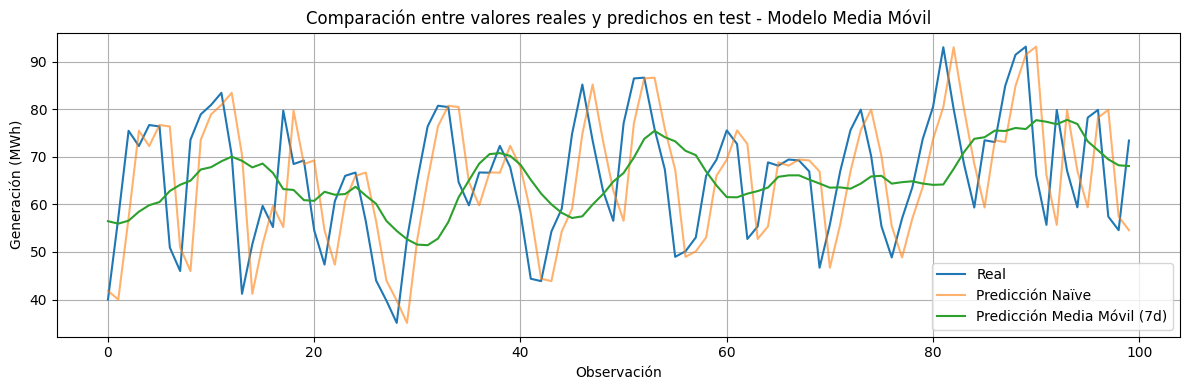

In [ ]:
# Definir número de observaciones a mostrar
n_mostrar = 100  # Número de puntos del test que se representarán

# Crear figura
plt.figure(figsize=(12, 4))  # Define el tamaño del gráfico

# Representar valores reales del test
plt.plot(y_test_real_ma[:n_mostrar], label="Real")  # Dibuja la serie real observada

# Representar predicciones naïve del test como referencia
plt.plot(y_test_pred[:n_mostrar], label="Predicción Naïve", alpha=0.6)  # Dibuja las predicciones del modelo naïve

# Representar predicciones de media móvil del test
plt.plot(y_test_pred_ma[:n_mostrar], label=f"Predicción Media Móvil ({window_size}d)")  # Dibuja las predicciones de la media móvil

# Añadir título
plt.title("Comparación entre valores reales y predichos en test - Modelo Media Móvil")  # Título del gráfico

# Añadir etiqueta del eje X
plt.xlabel("Observación")  # Identifica las observaciones del conjunto de test

# Añadir etiqueta del eje Y
plt.ylabel("Generación (MWh)")  # Indica la unidad de la variable objetivo

# Añadir leyenda
plt.legend()  # Muestra la identificación de cada línea

# Ajustar diseño
plt.tight_layout()  # Mejora la distribución visual del gráfico

# Mostrar gráfico
plt.show()  # Renderiza el gráfico

**Gráfico amplio de train, validation y test**

Este bloque representa la serie completa separando los tramos de entrenamiento, validación y test, y añade las predicciones de la media móvil en validación y test. Este gráfico permite visualizar el comportamiento del segundo modelo de referencia en el contexto completo de la serie temporal, de forma análoga al gráfico equivalente del modelo *naïve*.

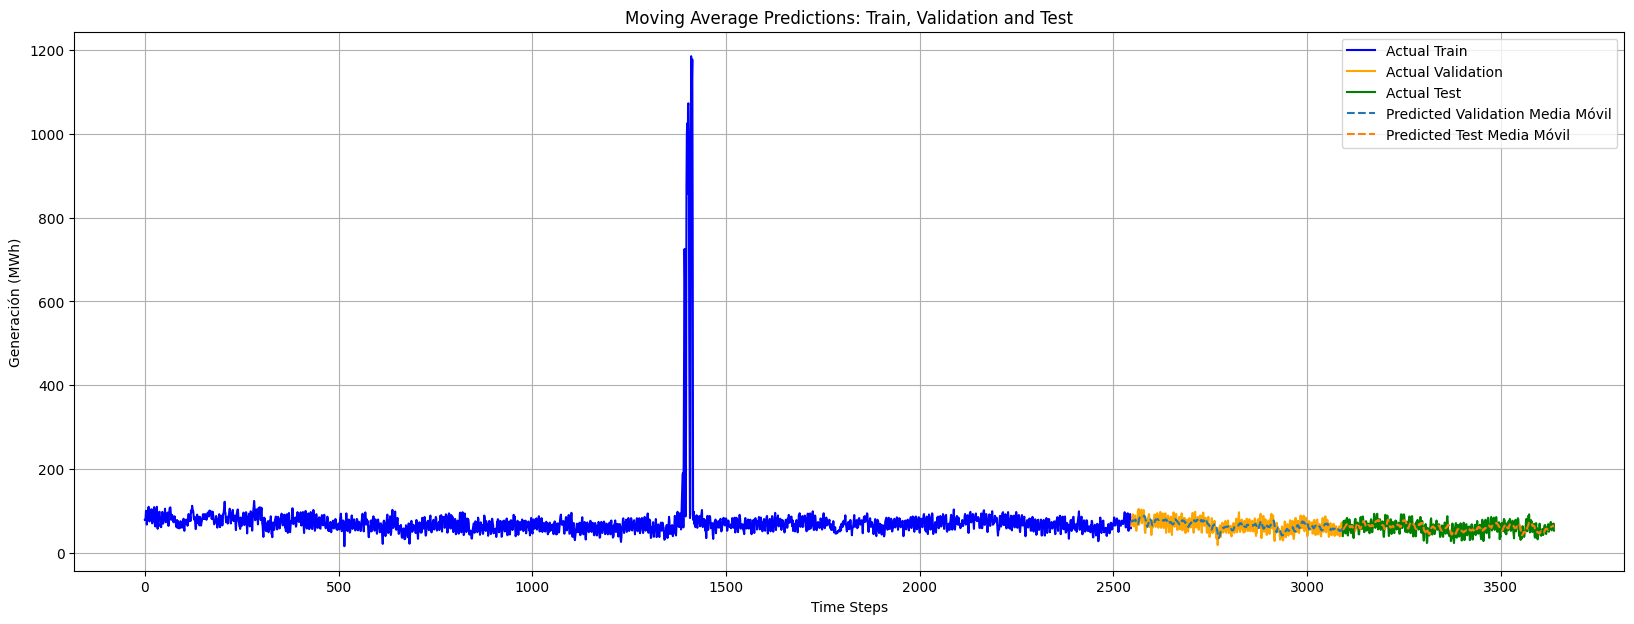

In [ ]:
# Crear eje temporal para train
train_time_steps = range(len(train))  # Índices temporales del tramo de entrenamiento

# Crear eje temporal para validation
val_time_steps = range(len(train), len(train) + len(val))  # Índices temporales del tramo de validación

# Crear eje temporal para test
test_time_steps = range(len(train) + len(val), len(train) + len(val) + len(test))  # Índices temporales del tramo de test

# Crear figura grande
plt.figure(figsize=(20, 7))  # Define un tamaño amplio para visualizar toda la serie

# Representar serie real de entrenamiento
plt.plot(train_time_steps, train, label="Actual Train", color="blue")  # Dibuja la serie real de entrenamiento

# Representar serie real de validación
plt.plot(val_time_steps, y_val_real_ma, label="Actual Validation", color="orange")  # Dibuja la serie real de validación

# Representar serie real de test
plt.plot(test_time_steps, y_test_real_ma, label="Actual Test", color="green")  # Dibuja la serie real de test

# Representar predicción de media móvil en validación
plt.plot(val_time_steps, y_val_pred_ma, label="Predicted Validation Media Móvil", linestyle="--")  # Dibuja predicciones de media móvil en validation

# Representar predicción de media móvil en test
plt.plot(test_time_steps, y_test_pred_ma, label="Predicted Test Media Móvil", linestyle="--")  # Dibuja predicciones de media móvil en test

# Añadir título
plt.title("Moving Average Predictions: Train, Validation and Test")  # Título del gráfico

# Añadir etiqueta del eje X
plt.xlabel("Time Steps")  # Identifica el eje temporal

# Añadir etiqueta del eje Y
plt.ylabel("Generación (MWh)")  # Indica la unidad de generación eléctrica

# Añadir leyenda
plt.legend()  # Muestra las etiquetas de cada serie

# Activar cuadrícula
plt.grid(True)  # Mejora la lectura visual

# Mostrar gráfico
plt.show()  # Renderiza la figura

 **Evolución del error del modelo de media móvil**

En este bloque final se analiza la evolución temporal del error absoluto del modelo de media móvil a lo largo de train, validation y test, de forma análoga al análisis realizado para el modelo *naïve*. El primer gráfico muestra el error absoluto en cada día de la serie, marcando los tramos de train, validation y test. El segundo gráfico complementa el análisis mediante un boxplot que sintetiza la distribución del error en cada conjunto, facilitando la detección de diferencias sistemáticas en magnitud o dispersión entre las tres particiones.

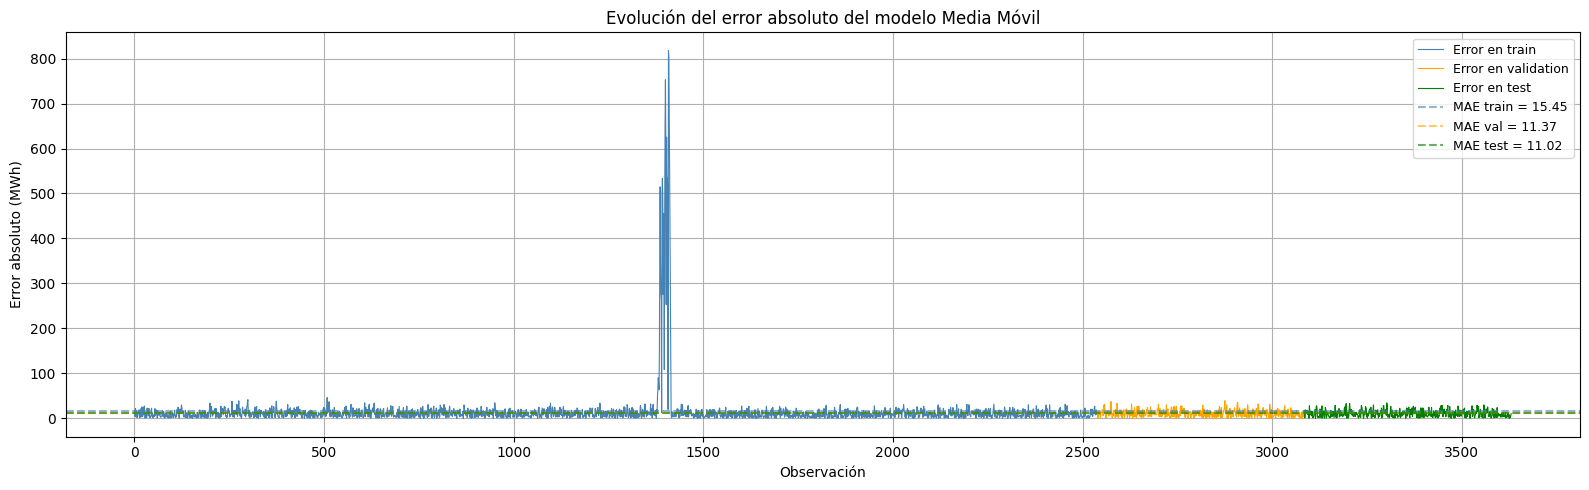

/tmp/ipykernel_274/4163205244.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(errores_ma, labels=["Train", "Validation", "Test"], showfliers=True)


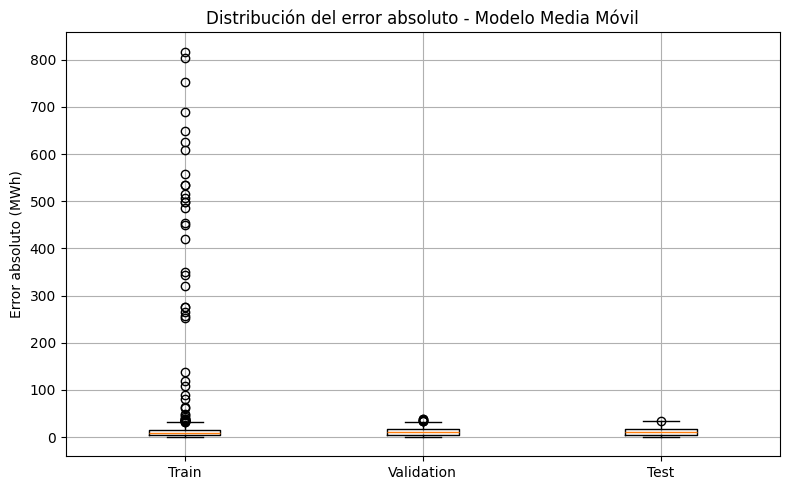

In [ ]:
# Calcular el error absoluto en train
err_train_ma = np.abs(y_train_real_ma - y_train_pred_ma)  # Error absoluto día a día en train

# Calcular el error absoluto en validation
err_val_ma = np.abs(y_val_real_ma - y_val_pred_ma)  # Error absoluto día a día en validation

# Calcular el error absoluto en test
err_test_ma = np.abs(y_test_real_ma - y_test_pred_ma)  # Error absoluto día a día en test

# Crear ejes temporales encadenados para representar todo en un mismo gráfico
x_train = np.arange(len(err_train_ma))                                          # Eje X de train
x_val = np.arange(len(err_train_ma), len(err_train_ma) + len(err_val_ma))       # Eje X de validation
x_test = np.arange(len(err_train_ma) + len(err_val_ma),
                   len(err_train_ma) + len(err_val_ma) + len(err_test_ma))      # Eje X de test

# Crear figura para la evolución temporal del error
plt.figure(figsize=(16, 5))  # Tamaño amplio para visualizar toda la serie

# Representar error absoluto en train
plt.plot(x_train, err_train_ma, label="Error en train", color="steelblue", linewidth=0.8)

# Representar error absoluto en validation
plt.plot(x_val, err_val_ma, label="Error en validation", color="orange", linewidth=0.8)

# Representar error absoluto en test
plt.plot(x_test, err_test_ma, label="Error en test", color="green", linewidth=0.8)

# Añadir línea horizontal con el MAE medio de cada conjunto
plt.axhline(mae_train_ma, color="steelblue", linestyle="--", alpha=0.6, label=f"MAE train = {mae_train_ma:.2f}")
plt.axhline(mae_val_ma, color="orange", linestyle="--", alpha=0.6, label=f"MAE val = {mae_val_ma:.2f}")
plt.axhline(mae_test_ma, color="green", linestyle="--", alpha=0.6, label=f"MAE test = {mae_test_ma:.2f}")

# Añadir título y etiquetas
plt.title("Evolución del error absoluto del modelo Media Móvil")
plt.xlabel("Observación")
plt.ylabel("Error absoluto (MWh)")
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

# Crear figura para el boxplot de los errores por conjunto
plt.figure(figsize=(8, 5))  # Tamaño moderado

# Construir lista con los tres arrays de error
errores_ma = [err_train_ma, err_val_ma, err_test_ma]  # Lista con los tres errores

# Representar boxplot
plt.boxplot(errores_ma, labels=["Train", "Validation", "Test"], showfliers=True)

# Añadir título y etiquetas
plt.title("Distribución del error absoluto - Modelo Media Móvil")
plt.ylabel("Error absoluto (MWh)")
plt.tight_layout()
plt.show()